In [8]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial # reduces arguments to function by making some subset implicit

from jax.example_libraries import stax

# visualization
import matplotlib.pyplot as plt
from functools import partial

from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)

gpu


In [9]:
def equation_of_motion(lagrangian, state, frc, t=None):
  q, q_t = jnp.split(state, 2)
  q_tt = (jnp.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t, frc))
          @ (jax.grad(lagrangian, 0)(q, q_t, frc) + frc
             - jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t, frc) @ q_t))
  return jnp.concatenate([q_t, q_tt])

def equation_of_motion_w_frc(lagrangian, state, frc_fn, t):
  q, q_t = jnp.split(state, 2)
  q_tt = (jnp.linalg.pinv(jax.hessian(lagrangian, 1)(q, q_t, frc_fn(t)))
          @ (jax.grad(lagrangian, 0)(q, q_t, frc_fn(t)) + frc_fn(t)
             - jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t, frc_fn(t)) @ q_t))
  return jnp.concatenate([q_t, q_tt])

def solve_lagrangian(lagrangian, initial_state, forcing, **kwargs):
  # We currently run odeint on CPUs only, because its cost is dominated by
  # control flow, which is slow on GPUs.
  @partial(jax.jit, backend='cpu')
  def f(initial_state):
    return odeint(lambda s,t: equation_of_motion(lagrangian, s, forcing),
                  initial_state, **kwargs)
  return f(initial_state)

def normalize_dp(state):
  # wrap generalized coordinates to [-pi, pi]
  return jnp.concatenate([
    (state[0] * 0)[None],
    (state[1])[None],
    (state[2] * 0)[None],
    state[3:]],
    )

def rk4_step(f, x, t, h):
  # one step of runge-kutta integration
  k1 = h * f(x, t)
  k2 = h * f(x + k1/2, t + h/2)
  k3 = h * f(x + k2/2, t + h/2)
  k4 = h * f(x + k3, t + h)
  return x + 1/6 * (k1 + 2 * k2 + 2 * k3 + k4)

In [10]:
import pickle 

with open('block_simulation_sample.pkl', 'rb') as f:
    block_data = pickle.load(f)

pos = jnp.array(block_data[:,:3])
vel = jnp.array(block_data[:,3:6])
forces = jnp.array(block_data[:,6:9])
acc = jnp.array(block_data[:,9:12])

train_test_split = int(0.8 * pos.shape[0])

x_train = jnp.concatenate([pos[:train_test_split], vel[:train_test_split]], axis=1)
xt_train = jnp.concatenate([vel[:train_test_split], acc[:train_test_split]], axis=1)
f_train = forces[:train_test_split]

x_test = jnp.concatenate([pos[train_test_split:], vel[train_test_split:]], axis=1)
xt_test = jnp.concatenate([vel[train_test_split:], acc[train_test_split:]], axis=1)
f_test = forces[train_test_split:]


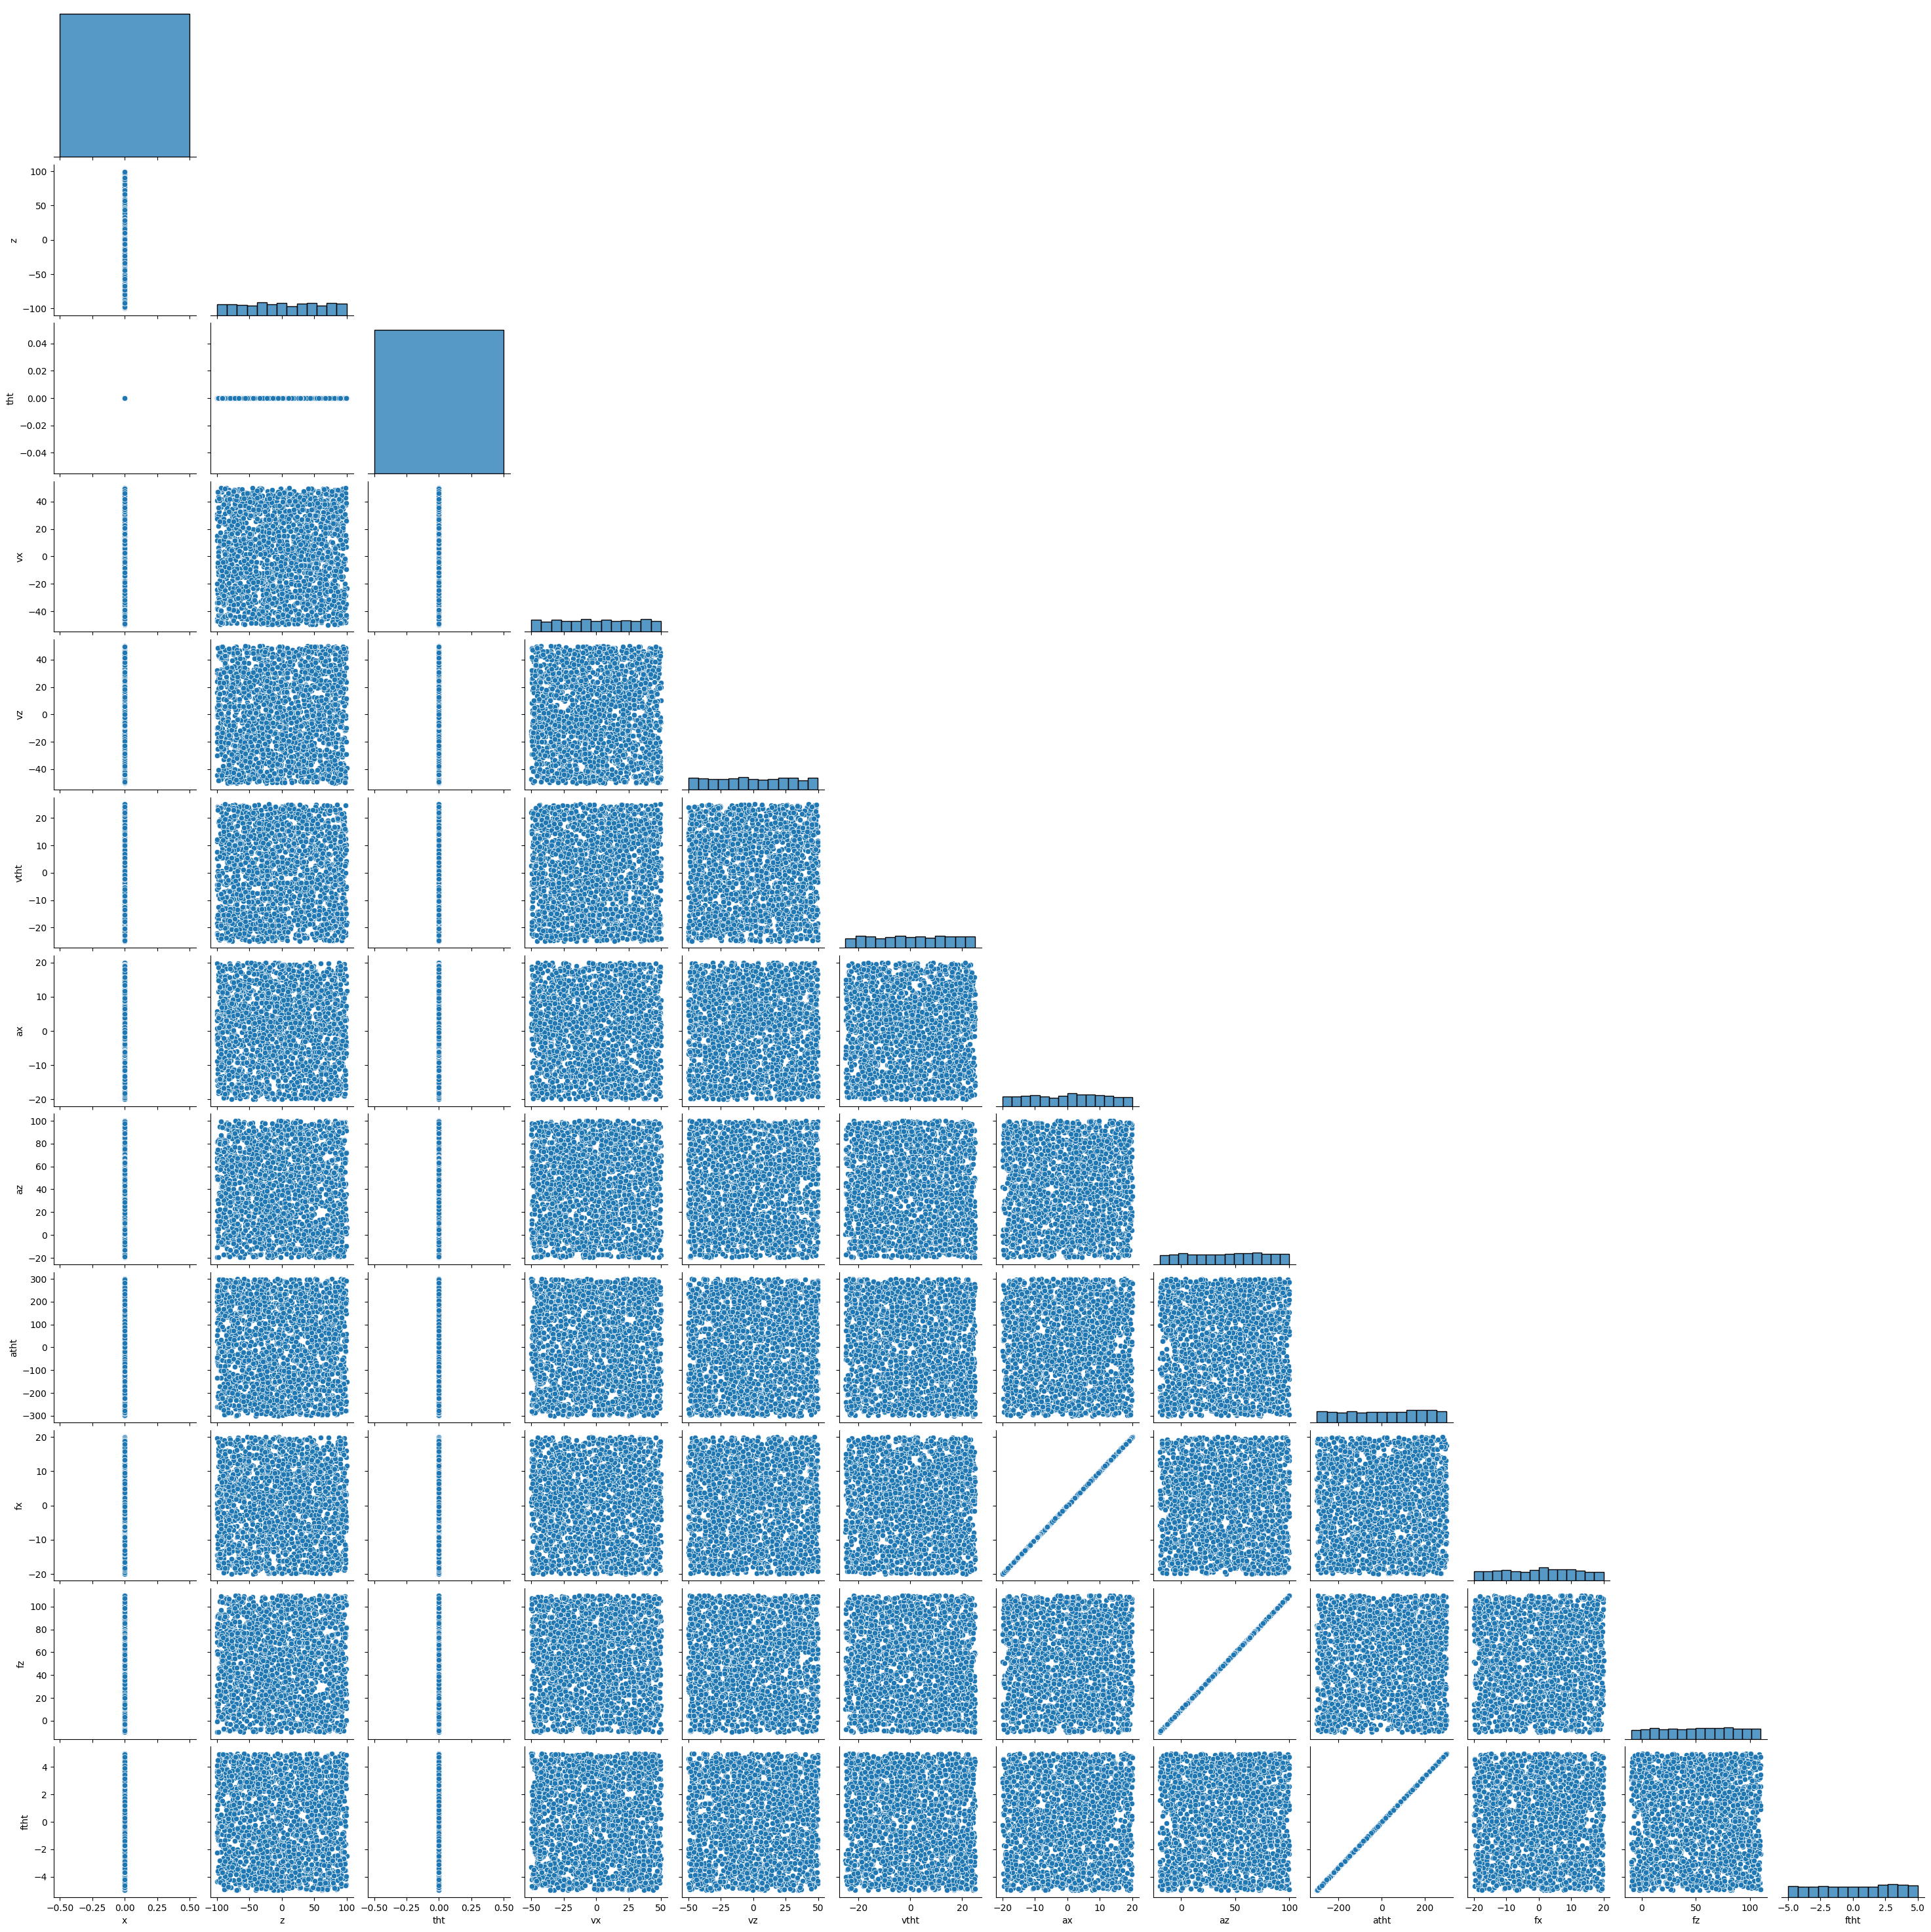

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# assume each is (N,3)
df = pd.DataFrame(
    np.hstack([pos, vel, acc, forces]),
    columns=[
      'x','z','tht',       # pos 
      'vx','vz','vtht',    # vel
      'ax','az','atht',    # acc
      'fx','fz','ftht'     # force
    ]
)
sns.pairplot(df.sample(2000), corner=True)  # sample to speed up
plt.show()


In [12]:
# replace the lagrangian with a parameteric model
def learned_lagrangian(params):
  def lagrangian(q, q_t, frc):
    assert q.shape == (3,)
    inp = normalize_dp(jnp.concatenate([q, q_t, frc]))
    return jnp.squeeze(nn_forward_fn_lnn(params, inp), axis=-1)
  return lagrangian

@partial(jax.jit, static_argnums=())
def batch_dynamics(params, states, forces):
    def single_eom(x, f):
        q, q_t = jnp.split(x, 2)
        L = learned_lagrangian(params)
        # use jacfwd+grad instead of full hessian for a 3×3 mass matrix
        M   = jax.jacfwd(jax.grad(L, argnums=1), argnums=1)(q, q_t, f)
        M_reg = M + 1e-4 * jnp.eye(M.shape[-1])   # add small diagonal
        dLdq = jax.grad(L, argnums=0)(q, q_t, f)
        C   = jax.jacfwd(jax.jacobian(L, argnums=1), argnums=0)(q, q_t, f)
        q_tt = jnp.linalg.solve(M_reg, dLdq + f - C @ q_t)
        # q_tt = jnp.linalg.pinv(M) @ (dLdq + f - C @ q_t)
        return jnp.concatenate([q_t, q_tt])
    return jax.vmap(single_eom)(states, forces)

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     return jnp.mean((preds - targets) ** 2)

# @jax.jit
# def loss(params, batch):
#     states, targets, forces = batch
#     preds = batch_dynamics(params, states, forces)
#     # L∞ = max |preds − targets|
#     return jnp.max(jnp.abs(preds - targets))

@jax.jit
def loss_lnn(params, batch):
    states, targets, forces = batch
    preds = batch_dynamics(params, states, forces)
    # compute |error| per element, then max over last axis (features),
    # then mean over batch axis
    per_sample_max = jnp.max(jnp.abs(preds - targets), axis=tuple(range(1, preds.ndim)))
    return jnp.mean(per_sample_max)

@jax.jit
def loss_mlp(params, batch):
    states, targets, forces = batch
    _, q_t = jnp.split(states, 2, axis=-1)
    inp = normalize_dp(jnp.concatenate([states, forces], axis=-1))
    preds = jnp.concatenate([q_t,nn_forward_fn_mlp(params, inp)], axis=-1)
    return jnp.mean((preds - targets) ** 2)


from jax.nn import initializers

init_random_params_lnn, nn_forward_fn_lnn = stax.serial(
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(1),
)

init_random_params_mlp, nn_forward_fn_mlp = stax.serial(
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(256),
    stax.Softplus,
    stax.Dense(3),
)

In [13]:
@jax.jit
def update_timestep(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, time_step), opt_state)

@jax.jit
def update_derivative(i, opt_state, batch):
  params = get_params(opt_state)
  return opt_update(i, jax.grad(loss)(params, batch, None), opt_state)

x_train = jax.vmap(normalize_dp)(x_train)
x_test = jax.vmap(normalize_dp)(x_test)


## LNN Training

In [ ]:
# %%time
import optax

rng_lnn = jax.random.PRNGKey(0)
_, init_params_lnn = init_random_params_lnn(rng_lnn, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 256
test_every = 10
num_batches = 1500 * 5

train_losses_lnn = []
test_losses_lnn = []
gns_lnn = []
lrs_lnn = []

total_steps = batch_size * num_batches

lr_schedule_lnn = optax.cosine_decay_schedule(
  init_value=5e-3, decay_steps=total_steps, alpha=1e-5
)

optimizer_lnn = optax.chain(
  optax.clip_by_global_norm(0.1),
  optax.adamw(learning_rate=lr_schedule_lnn, weight_decay=1e-4),
)

opt_state_lnn = optimizer_lnn.init(init_params_lnn)
params_lnn = init_params_lnn

@jax.jit
def train_step_lnn(params, opt_state, batch, step):
    grads = jax.grad(loss_lnn)(params, batch)
    gn = optax.global_norm(grads)
    lr = lr_schedule_lnn(step)
    updates, opt_state = optimizer_lnn.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, gn, lr

min_loss_lnn = 1e10
min_loss_params_lnn = None

for iteration in range(batch_size*num_batches + 1):
  if iteration % batch_size == 0:
    train_loss_lnn = loss_lnn(params_lnn, (x_train, xt_train, f_train))
    train_losses_lnn.append(train_loss_lnn)
    test_loss_lnn = loss_lnn(params_lnn, (x_test, xt_test, f_test))
    test_losses_lnn.append(test_loss_lnn)
    if iteration % (batch_size*test_every) == 0:
      print(f"iteration={iteration}, train_loss={train_loss_lnn:.6f}, test_loss={test_loss_lnn:.6f}, lr={lr_schedule_lnn(iteration):.6f}")
    params_lnn, opt_state_lnn, gn, lr = train_step_lnn(params_lnn, opt_state_lnn, (x_train, xt_train, f_train), iteration)
    gns_lnn.append(gn)
    lrs_lnn.append(lr)  

    if test_loss_lnn < min_loss_lnn:
      min_loss_lnn = test_loss_lnn
      min_loss_params_lnn = params_lnn

iteration=0, train_loss=348881.656250, test_loss=407273.031250, lr=0.005000
iteration=2560, train_loss=127836.695312, test_loss=30205.474609, lr=0.005000
iteration=5120, train_loss=22162.929688, test_loss=27883.429688, lr=0.005000
iteration=7680, train_loss=13060.169922, test_loss=14704.183594, lr=0.005000
iteration=10240, train_loss=10726.887695, test_loss=10680.852539, lr=0.005000
iteration=12800, train_loss=14343.166016, test_loss=7249.431641, lr=0.004999
iteration=15360, train_loss=16284.790039, test_loss=11366.260742, lr=0.004999
iteration=17920, train_loss=15652.634766, test_loss=12458.719727, lr=0.004999
iteration=20480, train_loss=15555.464844, test_loss=12159.009766, lr=0.004999
iteration=23040, train_loss=13914.158203, test_loss=20296.937500, lr=0.004998
iteration=25600, train_loss=18270.076172, test_loss=10771.960938, lr=0.004998
iteration=28160, train_loss=3980.192627, test_loss=3821.992188, lr=0.004997
iteration=30720, train_loss=4921.799805, test_loss=4960.679688, lr=0.00

KeyboardInterrupt: 

In [ ]:
import cloudpickle
to_save = {
  'params': min_loss_params_lnn,
  'apply_fn': nn_forward_fn_lnn,
  'normalize_fn': normalize_dp,
}
with open('lnn_model.pkl','wb') as f:
  cloudpickle.dump(to_save, f)

In [ ]:
plt.figure(figsize=(8, 8), dpi=120)
plt.subplot(3, 1, 1)
plt.plot(train_losses_lnn, label='Train loss')
plt.plot(test_losses_lnn, label='Test loss')
plt.yscale('log')
plt.title('Losses over training')
plt.xlabel("Train step") ; plt.ylabel("Mean squared error")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(gns_lnn)
plt.title('Gradient norm')
plt.xlabel("Train step") ; plt.ylabel("Gradient norm")
plt.yscale('log')

plt.subplot(3, 1, 3)
plt.plot(lrs_lnn)
plt.title('Learning rate')
plt.xlabel("Train step") ; plt.ylabel("Learning rate")
plt.yscale('log')
plt.tight_layout()

plt.show()

In [ ]:
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)
print(f"Min test loss: {min_loss_lnn:.6f}")
xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(min_loss_params_lnn)))(x_test, f_test)

sampl = xt_pred.shape[0]

k = 0
fig, axes = plt.subplots(2, 3, figsize=(12,6), dpi=120)
for i in range(2):
    for j in range(3):
        axes[i][j].scatter(xt_test[:sampl, k], xt_pred[:sampl, k], s=6, alpha=0.2)
        deriv = r'\dot' if i == 0 else r'\ddot'
        axes[i][j].set_title(fr'Predicting ${deriv} q{j}$')
        axes[i][j].set_xlabel(fr'${deriv} q{j}$ actual')
        axes[i][j].set_ylabel(fr'${deriv} q{j}$ predicted')
        plt.axis('equal')
        k += 1
plt.tight_layout()
plt.show()

## MLP Training

In [ ]:
# %%time
import optax

rng_mlp = jax.random.PRNGKey(0)
_, init_params_mlp = init_random_params_mlp(rng_mlp, (-1, 9))

# numbers in comments denote stephan's settings
batch_size = 256
test_every = 10
num_batches = 1500 * 5

train_losses_mlp = []
test_losses_mlp = []
gns_mlp = []
lrs_mlp = []

total_steps = batch_size * num_batches

lr_schedule_mlp = optax.cosine_decay_schedule(
  init_value=5e-3, decay_steps=total_steps, alpha=1e-5
)

optimizer_mlp = optax.chain(
  optax.clip_by_global_norm(0.1),
  optax.adamw(learning_rate=lr_schedule_mlp, weight_decay=1e-4),
)

opt_state_mlp = optimizer_mlp.init(init_params_mlp)
params_mlp = init_params_mlp

@jax.jit
def train_step_mlp(params, opt_state, batch, step):
    grads = jax.grad(loss_mlp)(params, batch)
    gn = optax.global_norm(grads)
    lr = lr_schedule_mlp(step)
    updates, opt_state = optimizer_mlp.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, gn, lr

min_loss_mlp = 1e10
min_loss_params_mlp = None

for iteration in range(batch_size*num_batches + 1):
  if iteration % batch_size == 0:
    train_loss_mlp = loss_mlp(params_mlp, (x_train, xt_train, f_train))
    train_losses_mlp.append(train_loss_mlp)
    test_loss_mlp = loss_mlp(params_mlp, (x_test, xt_test, f_test))
    test_losses_mlp.append(test_loss_mlp)
    if iteration % (batch_size*test_every) == 0:
      print(f"iteration={iteration}, train_loss={train_loss_mlp:.6f}, test_loss={test_loss_mlp:.6f}, lr={lr_schedule_mlp(iteration):.6f}")
    params_mlp, opt_state_mlp, gn, lr = train_step_mlp(params_mlp, opt_state_mlp, (x_train, xt_train, f_train), iteration)
    gns_mlp.append(gn)
    lrs_mlp.append(lr)  

    if test_loss_mlp < min_loss_mlp:
      min_loss_mlp = test_loss_mlp
      min_loss_params_mlp = params_mlp

In [ ]:
import cloudpickle
to_save = {
  'params': min_loss_params_mlp,
  'apply_fn': nn_forward_fn_mlp,
  'normalize_fn': normalize_dp,
}
with open('mlp_model.pkl','wb') as f:
  cloudpickle.dump(to_save, f)

In [ ]:
plt.figure(figsize=(8, 8), dpi=120)
plt.subplot(3, 1, 1)
plt.plot(train_losses_mlp, label='Train loss')
plt.plot(test_losses_mlp, label='Test loss')
plt.yscale('log')
plt.title('Losses over training')
plt.xlabel("Train step") ; plt.ylabel("Mean squared error")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(gns_mlp)
plt.title('Gradient norm')
plt.xlabel("Train step") ; plt.ylabel("Gradient norm")
plt.yscale('log')

plt.subplot(3, 1, 3)
plt.plot(lrs_mlp)
plt.title('Learning rate')
plt.xlabel("Train step") ; plt.ylabel("Learning rate")
plt.yscale('log')
plt.tight_layout()

plt.show()

In [ ]:
@jax.jit
def pred(params, batch):
    states, forces = batch
    _, q_t = jnp.split(states, 2, axis=-1)
    inp = normalize_dp(jnp.concatenate([states, forces], axis=-1))
    preds = jnp.concatenate([q_t,nn_forward_fn_mlp(params, inp)], axis=-1)
    return preds

In [ ]:
# xt_pred = jax.vmap(partial(equation_of_motion, learned_lagrangian(params)))(x_test, f_test)
print(f"Min test loss: {min_loss_mlp:.6f}")
xt_pred = jax.vmap(partial(pred, min_loss_params_mlp))((x_test, f_test))

sampl = xt_pred.shape[0]

k = 0
fig, axes = plt.subplots(2, 3, figsize=(12,6), dpi=120)
for i in range(2):
    for j in range(3):
        axes[i][j].scatter(xt_test[:sampl, k], xt_pred[:sampl, k], s=6, alpha=0.2)
        deriv = r'\dot' if i == 0 else r'\ddot'
        axes[i][j].set_title(fr'Predicting ${deriv} q{j}$')
        axes[i][j].set_xlabel(fr'${deriv} q{j}$ actual')
        axes[i][j].set_ylabel(fr'${deriv} q{j}$ predicted')
        plt.axis('equal')
        k += 1
plt.tight_layout()
plt.show()